This notebook is used to evaluate the models that are obtained from training:
- Evaluated Models:
    - Baseline model
    - PLReLU model
    - Pruned Model from Baseline model
    - INT8 Model from Baseline model (default config from Pytorch)
    - INT8 Model from PLReLU model (default config from Pytorch)
    - INT8 Model from PLReLU model (custem quantization based on Splitting-bit method)
- Measurements: model size, inference time, FLOPs, prameters.
- Draw graphs presenting quantization error of each layer to illustrate the behavior and sensitivity of each layer in the quantized models.

In [1]:
# Standard library
import copy
import glob
import multiprocessing
import os
import time
import zipfile
import psutil
# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# Related third party
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
from thop import profile

c:\FHDO\Research Thesis\project\embeddedNeuralNetwork\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [3]:
def print_model_size(mdl):
    torch.save(mdl.state_dict(), "tmp.pt")
    print("%.2f MB" %(os.path.getsize("tmp.pt")/1e6))
    os.remove('tmp.pt')

In [4]:
input_size = (224,224)
mean = [0.485, 0.456, 0.406] 
std = [0.229, 0.224, 0.225]
transform = transforms.Compose([
    transforms.Resize(input_size),  # Resize to a fixed size
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [5]:
class PLReLU(nn.Module):

    def __init__(self, init_alpha=0.1, init_beta=0.0):
        super().__init__()

        # learnable negative slope
        self.alpha = nn.Parameter(
            torch.tensor(init_alpha, dtype=torch.float32)
        )

        # learnable offset
        self.beta = nn.Parameter(
            torch.tensor(init_beta, dtype=torch.float32)
        )

    def forward(self, x):

        x_shifted = x - self.beta

        """
        Return the formula x_out = x - beta        if x > beta
                           x_out = alpha(x - beta) if x <= beta
        """
        return torch.where(
            x_shifted > 0,
            x_shifted,
            self.alpha * x_shifted
        )

class MobileNet(torch.nn.Module):
    def __init__(self):
        super(MobileNet, self).__init__()
        self.model = models.mobilenet_v2(weights='MobileNet_V2_Weights.IMAGENET1K_V1')  
        
        # for param in self.model.parameters():
        #     param.requires_grad = False
            
        
        
        self.model.classifier[1] = nn.Sequential(
            nn.Linear(in_features=self.model.classifier[1].in_features,out_features=512),
            nn.LeakyReLU(negative_slope=0.02,inplace=False),
            nn.BatchNorm1d(num_features=512),
            nn.Dropout(p=0.4,inplace=False),
            nn.Linear(in_features=512,out_features=2),
            nn.Softmax(dim=1))
        
        # print(self.model)

    def forward(self, x):
        x = self.model(x)
        return x
    
def replace_activation(module):

    for name, child in module.named_children():

        # ---------------------------------------------
        # Replace ReLU6
        # ---------------------------------------------
        if isinstance(child, nn.ReLU6):

            setattr(
                module,
                name,
                PLReLU(
                    init_alpha=0.1,
                    init_beta=0.0
                )
            )

            # print(f"Replaced ReLU6 at: {name}")

        # ---------------------------------------------
        # Replace LeakyReLU
        # ---------------------------------------------
        elif isinstance(child, nn.LeakyReLU):

            setattr(
                module,
                name,
                PLReLU(
                    init_alpha=child.negative_slope,
                    init_beta=0.0
                )
            )

            # print(f"Replaced LeakyReLU at: {name}")

        else:
            # recursive search
            replace_activation(child)

In [6]:
# Custom fake quantization combined with bit splitting method
from torch.ao.quantization.fake_quantize import FusedMovingAvgObsFakeQuantize


class SplitBitFusedFakeQuantize(FusedMovingAvgObsFakeQuantize):

    def forward(self, X):

        # ---------------------------------
        # inherit from FusedMovingAvgObsFakeQuantize to compute scale and zero point using observers
        # ---------------------------------

        if self.observer_enabled[0] == 1:

            self.activation_post_process(X.detach())

            scale, zero_point = self.calculate_qparams()

            self.scale.copy_(scale)
            self.zero_point.copy_(zero_point)

        # ---------------------------------
        # fake quantization process
        # ---------------------------------

        if self.fake_quant_enabled[0] == 1:

            # FP32 -> INT8
            X_int8 = torch.round(X / self.scale + self.zero_point)

            X_int8 = torch.clamp(X_int8, self.quant_min, self.quant_max)

            # X_int8 = X_int8.to(torch.uint8)

            # ---------------------------------
            # SPLIT-BIT: Split INT8 into 2 INT4
            # //2^4 and %2^4
            # ---------------------------------
            # n, m, h, w = X_int8.shape
            # X_int8 = X_int8.view(n,m,1,h,w)
            # X_int8 = X_int8.repeat(1,1,2,1,1)
            # X_int4 = torch.zeros((n,m,2,h,w), dtype=torch.int32)

            # X_int4[:,:,0,:,:] = X_int8 // 16
            # X_int4[:,:,1,:,:] = X_int8 % 16 



            high = X_int8 // 16
            low = X_int8 % 16

            # double-channel representation
            # -------------------------------------------------
            # view(n,m,1,h,w)
            # -------------------------------------------------
            if(X_int8.dim() == 4):

                # print(X_int8.shape)
                N, C, H, W = X_int8.shape

                X_split = X_int8.view(N, C, 1, H, W)
                X_split = X_split.repeat(1, 1, 2, 1, 1)

                # =================================================
                # store nibbles
                # =================================================

                X_split[:, :, 0, :, :] = high
                X_split[:, :, 1, :, :] = low

                # ---------------------------------
                # RECONSTRUCTION
                # ---------------------------------

                high_rec = X_split[:, :, 0, :, :] * 16
                low_rec = X_split[:, :, 1, :, :]

                X_rec_int8 = high_rec + low_rec
            else:
                X_rec_int8 = X_int8

            # ---------------------------------
            # INT8 -> FP32
            # ---------------------------------

            X_dequantize = (
                X_rec_int8.float() - self.zero_point
            ) * self.scale

            # ========================================
            # STE trick
            # ========================================

            X = X + (X_dequantize - X).detach()

        return X

In [7]:
# from torch.quantization.quantize_fx import prepare_fx, convert_fx,prepare_qat_fx
from torch.quantization.quantize_fx import prepare_qat_fx, prepare_fx, convert_fx
from torch.ao.quantization import QConfigMapping, get_default_qat_qconfig_mapping
from torch.ao.quantization.fx.custom_config import PrepareCustomConfig
from torch.ao.quantization import QConfig
from torch.ao.quantization.qconfig_mapping import QConfigMapping
from torch.ao.quantization.fake_quantize import default_fused_per_channel_wt_fake_quant

example_inputs = (torch.randn(1, 3, 224, 224),)
backend = 'onednn'
torch.backends.quantized.engine = backend

qconfig_mapping = (
    get_default_qat_qconfig_mapping(backend)
    # .set_module_name("features.1.conv.1", None)
    # .set_module_name("features.2.conv.0.0", None)
    # .set_module_name("features.2.conv.2", None)
)

custom_qconfig = QConfig(

    activation = SplitBitFusedFakeQuantize.with_args(
        observer = torch.ao.quantization.MovingAverageMinMaxObserver,
        quant_min=0,
        quant_max=255,
        dtype=torch.quint8,
        reduce_range=False
    ),
    weight = default_fused_per_channel_wt_fake_quant
)

prepare_custom_config = (
    PrepareCustomConfig()
    .set_non_traceable_module_classes(
        [PLReLU]
    )
)

custom_qconfig_mapping = QConfigMapping()
custom_qconfig_mapping = custom_qconfig_mapping.set_global(custom_qconfig)

In [8]:
def evaluate(model, criterion, data_loader, device,epoch):
    
    model.eval()
    
    epoch_loss = 0.0
    
    correct_predictions = 0
    total_predictions = 0
    
    num_batches = len(data_loader)
    
    with torch.no_grad():
       
        for image, target in tqdm(data_loader):
            image, target = image.to(device), target.to(device)
            output = model(image)
            loss = criterion(output, target)
            # Accumulate batch loss
            epoch_loss += loss.item()
            
            # Calculate accuracy
            _, predicted = torch.max(output, 1)  # Get the predicted class index
            correct_predictions += (predicted == target).sum().item()
            total_predictions += target.size(0)
            
    # Calculate average epoch loss
    avg_epoch_loss = epoch_loss / num_batches
    accuracy = correct_predictions / total_predictions
    
    print(f"Epoch = {epoch+1} || Validation Loss: {avg_epoch_loss:.4f} || Validation Accuracy: {accuracy:.4f}")
    return accuracy*100

def test_model(image_path, model, classes):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image)
    image_tensor = image_tensor.unsqueeze(0)
    # print(image_tensor.shape)
    with torch.no_grad():
        output = model(image_tensor)
        prob = torch.softmax(output, dim=1)
        pred = torch.argmax(prob, dim=1).item()

    print(f"Prediction: {classes[pred]} - {pred}")
    print(f"Confidence: {prob[0,pred]*100:.2f}%")


#=====Measure Inference Time===================
def measureInferenceTime(image_path, model, N):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image)
    image_tensor = image_tensor.unsqueeze(0)
    #====warm up========================
    # warm-up
    for _ in range(20):
        with torch.no_grad():
            model(image_tensor)
    #===================================

    start = time.perf_counter() # start counter
    for _ in range(N):
        with torch.no_grad():
            output = model(image_tensor)
    end = time.perf_counter() # end counter
    latency_ms = (end - start) * 1000 / N
    print(f"Inference Time is {latency_ms:.3f} ms")

#=====Measure FLOPs Computational Complexity (How many computations) and parameters=======
def measureFLOPs(image_path, model):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image)
    image_tensor = image_tensor.unsqueeze(0)
    flops, params = profile(
        model,
        inputs=(image_tensor,),
        verbose=False
    )
    # print(f"FLOPs: {flops/1e6:.2f} MFLOPs")
    # print(f"Params: {params/1e6:.2f} M")
    print(f"FLOPs: {flops} FLOPs")
    print(f"Params: {params}")

Load Model : Baseline Model, PLReLU Model

Pruned Model, 8-bit Quantized Model, 8-bit Quantized PLReLU Model, Splitting Bit Model

In [35]:
# Load Baseline Model
model = MobileNet()
model.load_state_dict(torch.load("../model/original_catndog_mobilenetv2.pth"))

# Load Pruned Model
prunedModel = torch.load("../model/best_pruned_model.pth", weights_only=False)

# Load PLReLU Model
PLReLUModel = MobileNet()
replace_activation(PLReLUModel)
PLReLUModel.load_state_dict(torch.load("../model/PLReLU_catndog_mobilenetv2.pth"))

# Load 8-bit quantized Model
quantizedModel = MobileNet()
prepared_model = prepare_qat_fx(quantizedModel, qconfig_mapping, example_inputs)
quantizedModel = convert_fx(prepared_model)
quantizedModel.load_state_dict(torch.load("../model/onlyWeight_Int8_catndog_mobilenetv2_epoch4.pth"))

# Load 8-bit quantized PLReLU Model
quantizedPLReLUModel = MobileNet()
replace_activation(quantizedPLReLUModel)
prepared_PLReLU_model = prepare_qat_fx(quantizedPLReLUModel, qconfig_mapping, example_inputs, prepare_custom_config=prepare_custom_config)
quantizedPLReLUModel = convert_fx(prepared_PLReLU_model)
quantizedPLReLUModel.load_state_dict(torch.load("../model/onlyWeight_int8_PLReLU_catndog_mobilenetv2_epoch4_loss0.317483.pth"))

# Load Spliting method PLReLU Model
quantizedSplitPLReLUModel = MobileNet()
replace_activation(quantizedSplitPLReLUModel)
prepared_PLReLU_split_model = prepare_qat_fx(quantizedSplitPLReLUModel, custom_qconfig_mapping, example_inputs, prepare_custom_config=prepare_custom_config)
quantizedSplitPLReLUModel = convert_fx(prepared_PLReLU_split_model)
quantizedSplitPLReLUModel.load_state_dict(torch.load("../model/onlyWeight_int8_PLReLU_Split_catndog_mobilenetv2_epoch4_loss0.315647.pth"))

# Model size
print("Size of Baseline Model:")
print_model_size(model)
print("Size of PLReLU Model:")
print_model_size(PLReLUModel)
print("Size of Pruned Model:")
print_model_size(prunedModel)
print("Size of 8-bit Quantized Model:")
print_model_size(quantizedModel)
print("Size of 8-bit Quantized PLReLU Model:")
print_model_size(quantizedPLReLUModel)
print("Size of 8-bit Quantized Split PLReLU Model:")
print_model_size(quantizedSplitPLReLUModel)


C:\Users\nvdao\AppData\Local\Temp\ipykernel_22236\414171242.py:15: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared_model = prepare_qat_fx(quantizedModel, qconfig_mapping, example_inputs)
C:\Users\nvdao\AppData\Local\Temp\ipykernel_22236\414171242.py:16: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 


Size of Baseline Model:
11.76 MB
Size of PLReLU Model:
11.78 MB
Size of Pruned Model:
4.50 MB
Size of 8-bit Quantized Model:
3.30 MB
Size of 8-bit Quantized PLReLU Model:
3.34 MB
Size of 8-bit Quantized Split PLReLU Model:
3.34 MB


In [11]:
# Measure FLOPs and Inference Time
classes = ["Dog", "Cat"]
print("Evaluating original model...")

#====================INFERENCE TIME=========================
# Inference Time of baseline model
print("Baseline Model")
measureInferenceTime("dog.jpg", model, 100)
# Inference Time of PLReLU Model
print("PLReLU Model")
measureInferenceTime("dog.jpg", PLReLUModel, 100)
# Inference Time of Pruned Model
print("Pruned Model")
measureInferenceTime("dog.jpg", prunedModel, 100)
# Inference Time of 8-bit Quantized Model
print("8-bit Quantized Model")
measureInferenceTime("dog.jpg", quantizedModel, 100)
# Inference Time of 8-bit Quantized PLReLU Model
print("8-bit Quantized PLReLU Model")
measureInferenceTime("dog.jpg", quantizedPLReLUModel, 100)
# Inference Time of 8-bit Quantized Split PLReLU Model
print("8-bit Quantized Split PLReLU Model")
measureInferenceTime("dog.jpg", quantizedSplitPLReLUModel, 100)
#====================================================

#====================FLOPS===========================
# FLOPs of baseline model
print("Baseline Model")
measureFLOPs("dog.jpg", model)
# FLOPs of PLReLU Model
print("PLReLU Model")
measureFLOPs("dog.jpg", PLReLUModel)
# FLOPs of Pruned Model
print("Pruned Model")
measureFLOPs("dog.jpg", prunedModel)
# FLOPs of 8-bit Quantized Model
print("8-bit Quantized Model")
measureFLOPs("dog.jpg", quantizedModel)
# FLOPs of 8-bit Quantized PLReLU Model
print("8-bit Quantized PLReLU Model")
measureFLOPs("dog.jpg", quantizedPLReLUModel)
# FLOPs of 8-bit Quantized Split PLReLU Model
print("8-bit Quantized Split PLReLU Model")
measureFLOPs("dog.jpg", quantizedSplitPLReLUModel)
#====================================================
total_channels = []
for name, module in model.named_modules():

    if isinstance(module, nn.Conv2d):

        out_ch = module.out_channels
        total_channels.append(out_ch)
print(f"total channels: {sum(total_channels)}")


# measure Memory Usage
# process = psutil.Process(os.getpid())
# mem_before = process.memory_info().rss
# #---------model---------------------
# test_model("dog.jpg", model, classes)
# #-----------------------------------
# mem_after = process.memory_info().rss
# print((mem_after - mem_before) / (1024*1024), "MB")


Evaluating original model...
Baseline Model
Inference Time is 15.546 ms
PLReLU Model
Inference Time is 22.101 ms
Pruned Model
Inference Time is 12.909 ms
8-bit Quantized Model
Inference Time is 7.955 ms
8-bit Quantized PLReLU Model
Inference Time is 52.537 ms
8-bit Quantized Split PLReLU Model
Inference Time is 51.817 ms
Baseline Model
FLOPs: 326865157.0 FLOPs
Params: 2881794.0
PLReLU Model
FLOPs: 326865157.0 FLOPs
Params: 2881794.0
Pruned Model
FLOPs: 197839320.0 FLOPs
Params: 1078227.0
8-bit Quantized Model
FLOPs: 2048.0 FLOPs
Params: 1024.0
8-bit Quantized PLReLU Model
FLOPs: 2048.0 FLOPs
Params: 1024.0
8-bit Quantized Split PLReLU Model
FLOPs: 2053.0 FLOPs
Params: 1024.0
total channels: 17056


Quantization Error per Layer

In [36]:
import torch.nn.functional as F

#====================================
#    Register Forward Hook
#====================================
fp32_outputs = {}
int8_outputs = {}

def get_hook(outputs, name):
    def hook(module, input, output):
        outputs[name] = output.detach().cpu()
    return hook

# Load Baseline Model
# model
# Load Pruned Model
# prunedModel
# Load PLReLU Model
# PLReLUModel
# Load 8-bit quantized Model
# quantizedModel
# Load 8-bit quantized PLReLU Model
# quantizedPLReLUModel
# Load Spliting method PLReLU Model
# quantizedSplitPLReLUModel

# FP32 baseline model

baselineModel = PLReLUModel
compareModel = quantizedSplitPLReLUModel
for name, module in baselineModel.named_modules():
    if isinstance(module, nn.Conv2d):
        # print(name, module.__class__.__name__)
        module.register_forward_hook(get_hook(fp32_outputs, name))

# static 8-bit Quantized model
for name, module in compareModel.named_modules():
    # print(name, module.__class__.__name__)
    # if isinstance(module, nn.Conv2d):
    if module.__class__.__name__ == "Conv2d":
        module.register_forward_hook(get_hook(int8_outputs, name))

#===================================================
#         Run model with an image
#===================================================
baselineModel.eval()
compareModel.eval()

image_path = "dog.jpg"
with torch.no_grad():
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image)
    image_tensor = image_tensor.unsqueeze(0)
    baselineModel(image_tensor)
    compareModel(image_tensor)




#===================================================
#     Compute Mean Sqared Error
#===================================================

layer_error = {}

for name in fp32_outputs:

    fp = fp32_outputs[name].float()

    qt = int8_outputs[name].dequantize().float() \
         if int8_outputs[name].is_quantized \
         else int8_outputs[name].float()

    mse = F.mse_loss(fp, qt)

    layer_error[name] = mse.item()

In [39]:
print(baselineModel)

MobileNet(
  (model): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): PLReLU()
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): PLReLU()
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, kernel_

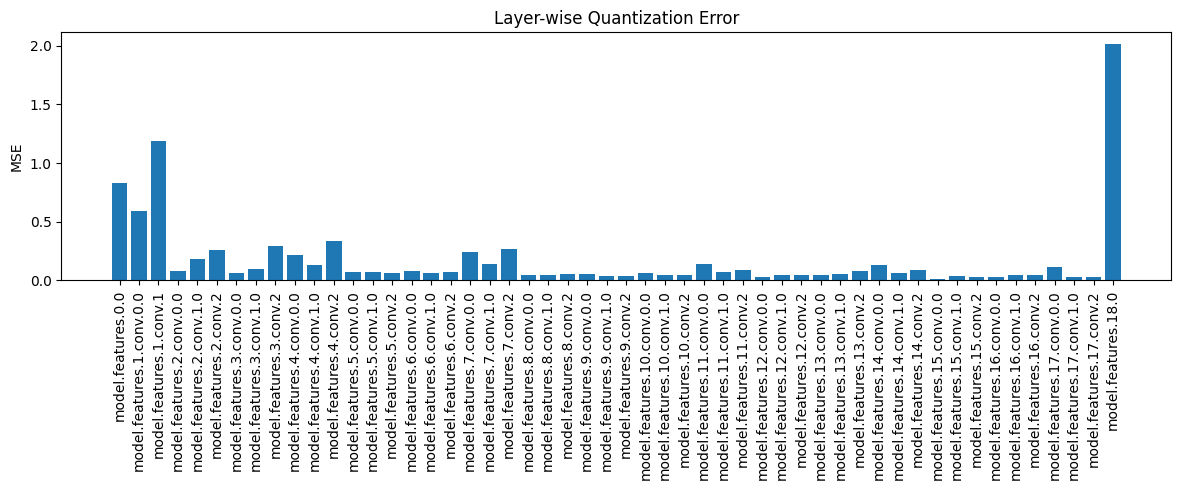

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.bar(layer_error.keys(),
        layer_error.values())

plt.xticks(rotation=90)

plt.ylabel("MSE")

plt.title("Layer-wise Quantization Error")

plt.tight_layout()

plt.show()